LAB 1 – Dự đoán giá cổ phiếu
• Mục tiêu: Dự báo giá đóng cửa ngày tiếp theo
• Dữ liệu: Yahoo Finance (AAPL, BTC-USD)
• Yêu cầu:
1. Thu thập dữ liệu giá OHLC
2. Tạo feature từ giá đóng cửa (lag 1, 2, 3)
3. Huấn luyện Linear Regression, SVM và XGBoot
4. Đánh giá bằng MAE, RMSE với các mô hình trên
5. Vẽ biểu đồ dự đoán vs thực tế


In [2]:
!pip install xgboost

[*********************100%***********************]  1 of 1 completed
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== MODEL EVALUATION ===
Linear Regression: MAE = 1.60, RMSE = 2.11
SVM: MAE = 17.99, RMSE = 23.57
XGBoost: MAE = 7.89, RMSE = 10.68


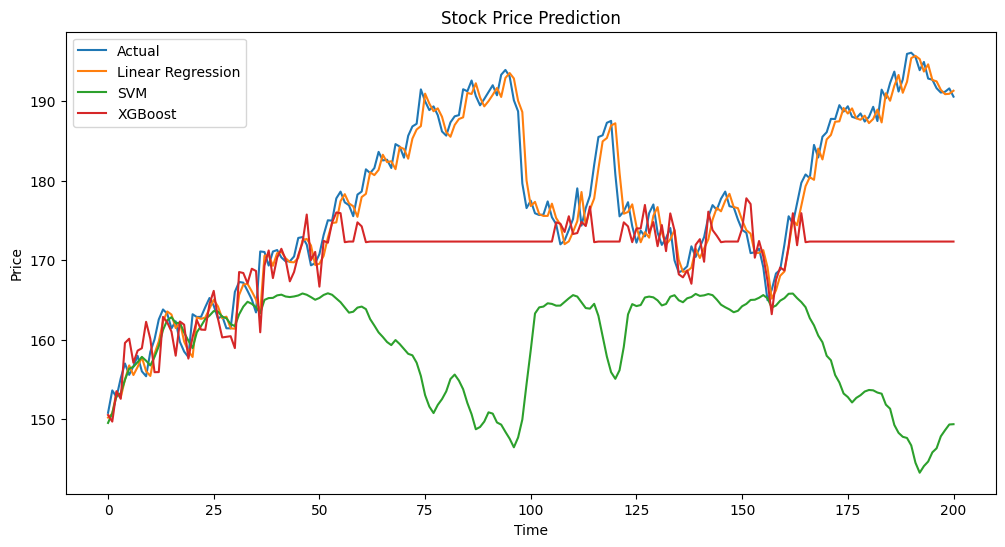

In [3]:
# ================== LAB 1: STOCK PRICE PREDICTION ==================

# 1. Import thư viện
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. Load dữ liệu (AAPL hoặc BTC-USD)
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# 3. Feature Engineering (lag 1,2,3)
df = df[['Close']]
df['lag1'] = df['Close'].shift(1)
df['lag2'] = df['Close'].shift(2)
df['lag3'] = df['Close'].shift(3)
df.dropna(inplace=True)

# 4. Train/Test split (time series)
X = df[['lag1', 'lag2', 'lag3']]
y = df['Close']

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. Train models
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# SVM
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# 6. Evaluation
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

print("=== MODEL EVALUATION ===")
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_xgb, "XGBoost")

# 7. Plot
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Linear Regression')
plt.plot(y_pred_svm, label='SVM')
plt.plot(y_pred_xgb, label='XGBoost')

plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

# ================================================================

LAB 2 – Phân loại xu hướng giá
• Mục tiêu: Phân loại Up/Down
• Dữ liệu: Yahoo Finance
• Yêu cầu:
1. Tạo label: Up (1) nếu return > 0
2. Trích xuất feature kỹ thuật
3. Huấn luyện Logistic Regression, SVM và XGBoot
4. Đánh giá accuracy, F1-score
5. Phân tích confusion matrix 

[*********************100%***********************]  1 of 1 completed
C:\Users\Asus\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:08:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== MODEL EVALUATION ===
Logistic Regression: Accuracy = 0.558, F1 = 0.611
SVM: Accuracy = 0.503, F1 = 0.434
XGBoost: Accuracy = 0.508, F1 = 0.402


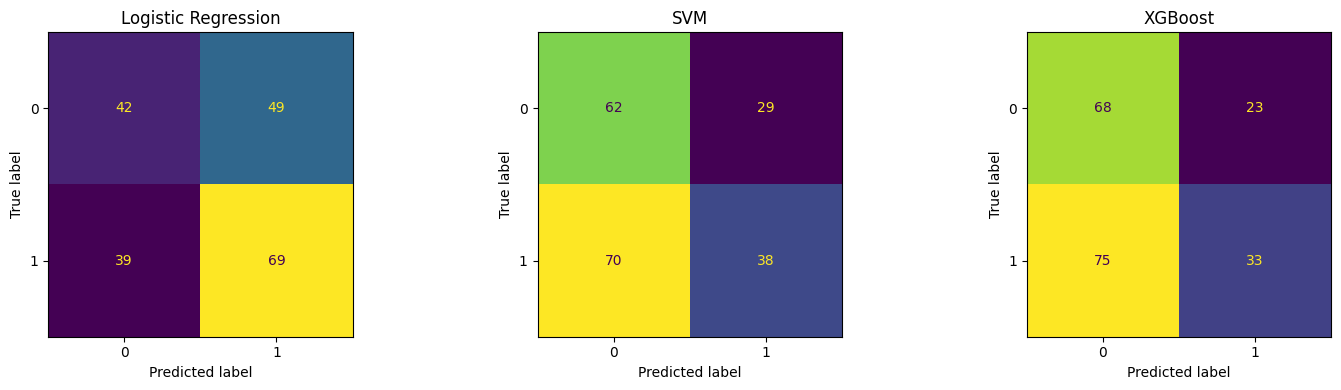

In [4]:
# ================== LAB 2: CLASSIFY STOCK TREND ==================

# 1. Import thư viện
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Load dữ liệu
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# 3. Tạo label (Up/Down)
df['return'] = df['Close'].pct_change()
df['label'] = (df['return'] > 0).astype(int)

# 4. Feature kỹ thuật
df['ma5'] = df['Close'].rolling(5).mean()
df['ma10'] = df['Close'].rolling(10).mean()
df['std5'] = df['Close'].rolling(5).std()

# RSI (đơn giản)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))

# Drop NA
df.dropna(inplace=True)

# 5. Train/Test split
features = ['ma5', 'ma10', 'std5', 'rsi']
X = df[features]
y = df['label']

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. Train models
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# 7. Evaluation
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name}: Accuracy = {acc:.3f}, F1 = {f1:.3f}")

print("=== MODEL EVALUATION ===")
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_xgb, "XGBoost")

# 8. Confusion Matrix
models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

plt.figure(figsize=(15,4))

for i, (name, y_pred) in enumerate(models.items()):
    plt.subplot(1,3,i+1)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(name)

plt.tight_layout()
plt.show()

# ================================================================

LAB 3 – Feature engineering với chỉ báo kỹ thuật
• Mục tiêu: Tăng chất lượng feature
• Dữ liệu: Yahoo Finance
• Yêu cầu:
1. Tính MA, RSI, MACD
2. Chuẩn hóa dữ liệu
3. Train Random Forest, Decision Tree và Bayes
4. Đánh giá mô hình
5. Phân tích feature importance 

[*********************100%***********************]  1 of 1 completed


=== MODEL EVALUATION ===
Random Forest: Accuracy = 0.477, F1 = 0.316
Decision Tree: Accuracy = 0.543, F1 = 0.577
Naive Bayes: Accuracy = 0.508, F1 = 0.473


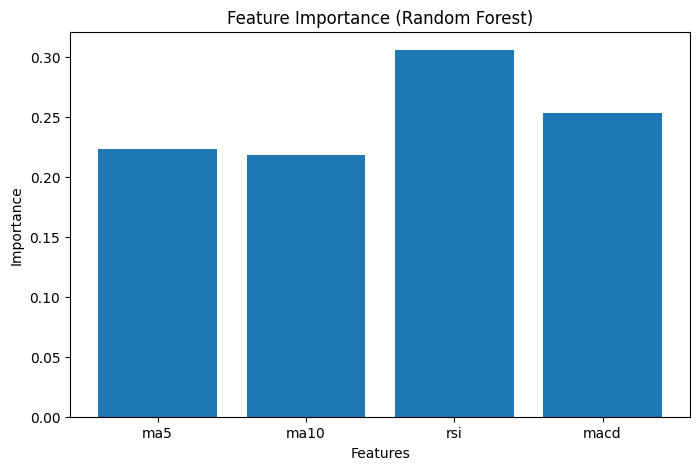

In [5]:
# ================== LAB 3: FEATURE ENGINEERING ==================

# 1. Import thư viện


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, f1_score

# 2. Load dữ liệu
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# 3. Tạo label
df['return'] = df['Close'].pct_change()
df['label'] = (df['return'] > 0).astype(int)

# ================= FEATURE ENGINEERING =================

# MA
df['ma5'] = df['Close'].rolling(5).mean()
df['ma10'] = df['Close'].rolling(10).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['macd'] = ema12 - ema26

# Drop NA
df.dropna(inplace=True)

# ================= DATA PREP =================

features = ['ma5', 'ma10', 'rsi', 'macd']
X = df[features]
y = df['label']

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
split = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

# ================= MODEL =================

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# ================= EVALUATION =================

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name}: Accuracy = {acc:.3f}, F1 = {f1:.3f}")

print("=== MODEL EVALUATION ===")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_nb, "Naive Bayes")

# ================= FEATURE IMPORTANCE =================

importances = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# =====================================================

LAB 4 – Dự đoán return
• Mục tiêu: Dự báo return thay vì giá
• Dữ liệu: Crypto/Stock
• Yêu cầu:
1. Tính return hàng ngày
2. Xây dựng feature lag
3. Train model Regression
4. Đánh giá RMSE
5. So sánh với baseline

[*********************100%***********************]  1 of 1 completed


=== RMSE ===
Baseline: 0.021340
Linear Regression: 0.021153
Random Forest: 0.022713
XGBoost: 0.026859


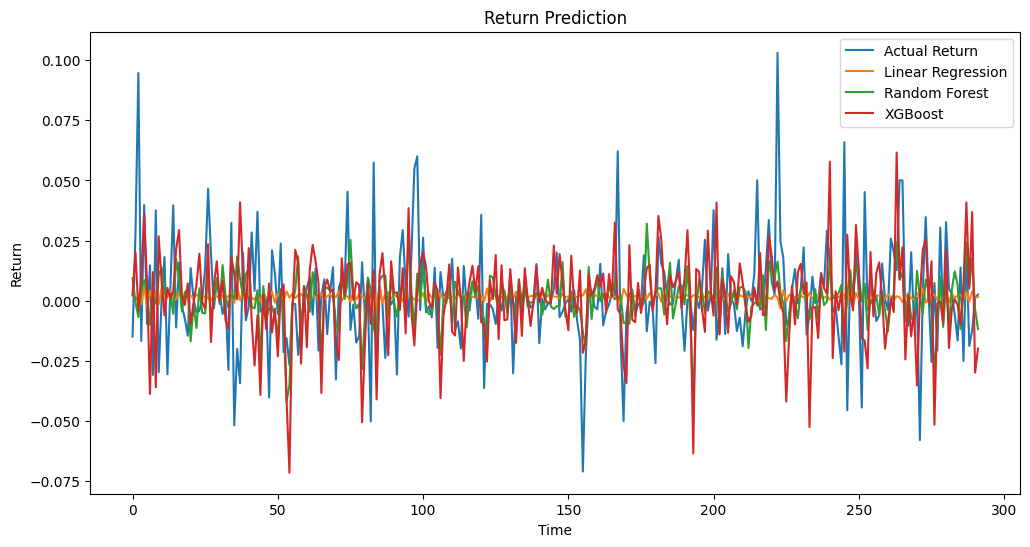

In [6]:
# ================== LAB 4: RETURN PREDICTION ==================

# 1. Import thư việnt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

# 2. Load dữ liệu (có thể đổi BTC-USD)
df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")

# 3. Tính return hàng ngày
df['return'] = df['Close'].pct_change()

# 4. Feature lag
df['lag1'] = df['return'].shift(1)
df['lag2'] = df['return'].shift(2)
df['lag3'] = df['return'].shift(3)

# Drop NA
df.dropna(inplace=True)

# 5. Data prep
features = ['lag1', 'lag2', 'lag3']
X = df[features]
y = df['return']

# Train/Test split
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================= MODEL =================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ================= BASELINE =================
# baseline: dự đoán return = 0
y_pred_base = np.zeros_like(y_test)

# ================= EVALUATION =================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("=== RMSE ===")
print(f"Baseline: {rmse(y_test, y_pred_base):.6f}")
print(f"Linear Regression: {rmse(y_test, y_pred_lr):.6f}")
print(f"Random Forest: {rmse(y_test, y_pred_rf):.6f}")
print(f"XGBoost: {rmse(y_test, y_pred_xgb):.6f}")

# ================= PLOT =================

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Return')
plt.plot(y_pred_lr, label='Linear Regression')
plt.plot(y_pred_rf, label='Random Forest')
plt.plot(y_pred_xgb, label='XGBoost')

plt.legend()
plt.title("Return Prediction")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

# =============================================================

LAB 5 – Dự đoán volatility
• Mục tiêu: Ước lượng biến động
• Dữ liệu: Stock data
• Yêu cầu:
1. Tính rolling std
2. Tạo feature kỹ thuật
3. Train Random Forest
4. Đánh giá sai số
5. So sánh với historical volatility 


[*********************100%***********************]  1 of 1 completed


RMSE: 0.0012428415330821062


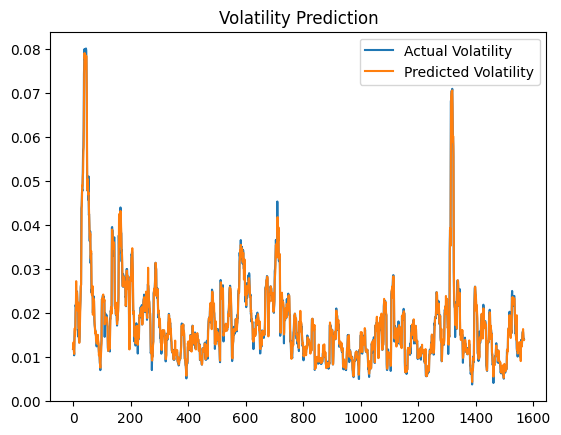

In [8]:
df = yf.download("AAPL", start="2020-01-01")

# Tính return và volatility
df['return'] = df['Close'].pct_change()
df['vol'] = df['return'].rolling(10).std()

# Feature lag
df['lag1'] = df['vol'].shift(1)
df.dropna(inplace=True)

X = df[['lag1']]
y = df['vol']

# Train
model = RandomForestRegressor()
model.fit(X, y)
pred = model.predict(X)

# Đánh giá
rmse = np.sqrt(mean_squared_error(y, pred))
print("RMSE:", rmse)

# 📊 Plot
plt.figure()
plt.plot(y.values, label="Actual Volatility")
plt.plot(pred, label="Predicted Volatility")
plt.legend()
plt.title("Volatility Prediction")
plt.show()

LAB 6 – TimeSeriesSplit   
• Mục tiêu: Cross-validation đúng cách  
• Dữ liệu: Stock  
• Yêu cầu:  
1. Áp dụng TimeSeriesSplit  
2. Train model mỗi fold  
3. Tính trung bình RMSE  
4. So sánh với KFold  
5. Phân tích leakage  

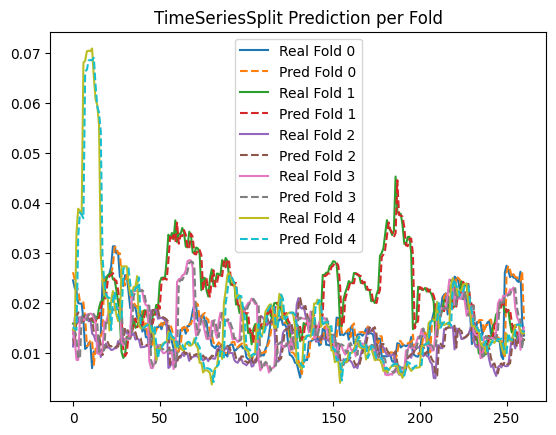

Average RMSE: 0.0024262639485130846


In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
model = LinearRegression()

rmses = []

plt.figure()

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y_train, y_test = y.values[train_idx], y.values[test_idx]
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmses.append(rmse)
    
    # 📊 Plot từng fold
    plt.plot(range(len(y_test)), y_test, label=f"Real Fold {i}")
    plt.plot(range(len(pred)), pred, linestyle='--', label=f"Pred Fold {i}")

plt.legend()
plt.title("TimeSeriesSplit Prediction per Fold")
plt.show()

print("Average RMSE:", np.mean(rmses))

LAB 07 – Lag features nâng cao  -• Mục tiêu: Khai thác tempora  structure-
• Dữ liệu: Stoc-
• Yêu c  ầu:
1. Tạo lag 1–10
2. Train model
3. Feature selection
4. Đánh giá
5. So sánh số lag

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


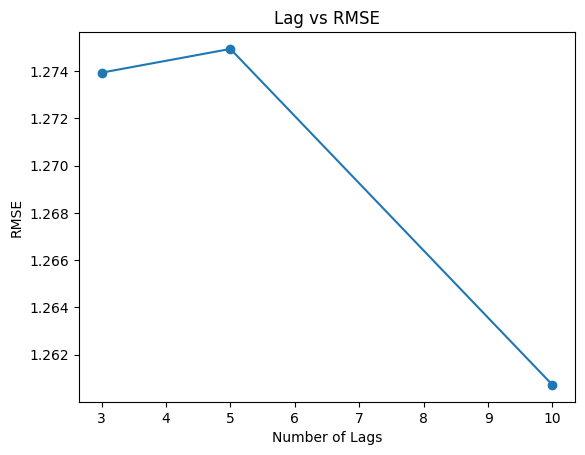

In [11]:

results = []

for lag in [3,5,10]:
    temp = df.copy()
    
    for i in range(1, lag+1):
        temp[f'lag_{i}'] = temp['Close'].shift(i)
    
    temp.dropna(inplace=True)
    
    X = temp[[f'lag_{i}' for i in range(1, lag+1)]]
    y = temp['Close']
    
    model = RandomForestRegressor()
    model.fit(X, y)
    pred = model.predict(X)
    
    rmse = np.sqrt(mean_squared_error(y, pred))
    results.append((lag, rmse))

# 📊 Plot
lags = [r[0] for r in results]
errors = [r[1] for r in results]

plt.figure()
plt.plot(lags, errors, marker='o')
plt.title("Lag vs RMSE")
plt.xlabel("Number of Lags")
plt.ylabel("RMSE")
plt.show()

LAB 08 – PCA
• Mục tiêu: Giảm chiều
• Dữ liệu: Multi-feature
• Yêu cầu:
1. Apply PCA
2. Chọn số component
3. Train model
4. Evaluate
5. Visualize

[*********************100%***********************]  1 of 1 completed


Explained variance: [0.66613435 0.33347198]


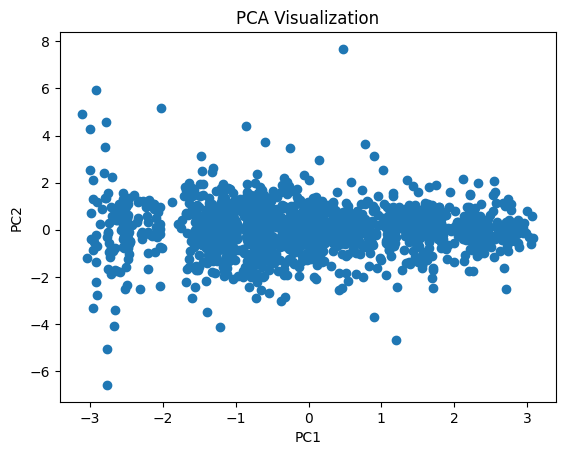

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Tạo feature
df = yf.download("AAPL", start="2020-01-01")
df['return'] = df['Close'].pct_change()
df['ma'] = df['Close'].rolling(5).mean()
df.dropna(inplace=True)

X = df[['Close','return','ma']]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

# 📊 Plot PCA
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

LAB 09: Clustering cổ phiếu
• Mục tiêu: Phân nhóm
• Dữ liệu: Multi-stock
• Yêu cầu:
1. Extract features
2. KMeans clustering
3. Evaluate clusters
4. Visualize kết quả
5. Phân tích 

[*********************100%***********************]  4 of 4 completed
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clusters: [0 0 1 0]


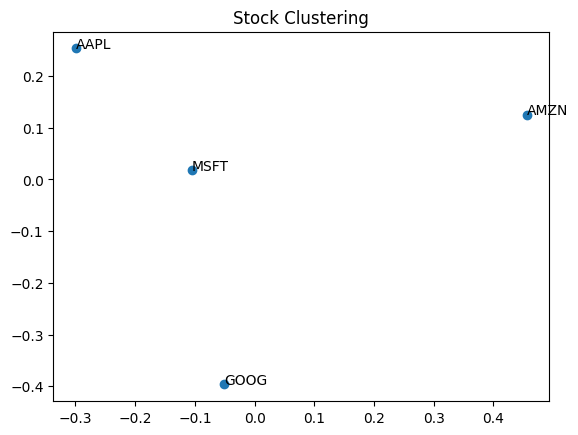

In [15]:
from sklearn.cluster import KMeans

# Load nhiều cổ phiếu
df = yf.download(["AAPL","MSFT","GOOG","AMZN"], start="2020-01-01")['Close']

returns = df.pct_change().dropna()

# Transpose để mỗi stock là 1 điểm
X = returns.T

# KMeans
kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(X)

print("Clusters:", clusters)

# 📊 PCA để visualize
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, stock in enumerate(X.index):
    plt.text(X_pca[i,0], X_pca[i,1], stock)

plt.title("Stock Clustering")
plt.show()